# Linear Regression

**Aim** is to understand the dependency of a target variable as a linear relationship with independent variable(s). 

- Simple LR: refers to one independent variable to make a prediction. 

- Multiple LR: multiple independent variables to make a prediction

Data is usually stored in NumPy arrays. In  $y = mx + c$ m and c are the parameters that needs to be found through the data

In [ ]:
#!pip install scikit-learn

In [126]:
from sklearn.linear_model import LinearRegression
import pandas as pd
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt

In [125]:
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_squared_error, r2_score

In [9]:
df = pd.read_csv("C:/Users/himan/Downloads/automobileEDA.csv")

In [151]:
#single variable linear regression
lm = LinearRegression()
X = df[['highway-mpg']]
Y = df['price']
display(lm.fit(X,Y))
slope = lm.coef_
intercept = lm.intercept_
print(slope , intercept)

#ERRORS
print(f"the R-squared value of the best fit is {lm.score(X,Y)}") #R-squared value
Yhat = lm.predict(X)
mse = mean_squared_error(df['price'] , Yhat) #mean squared error
print(mse)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


[-821.73337832] 38423.3058581574
the R-squared value of the best fit is 0.4965911884339176
31635042.944639888


In [149]:

X = df['highway-mpg']
Y = df['price']
f = np.polyfit(X , Y , 1)
p = np.poly1d(f)
print(p)

 
-821.7 x + 3.842e+04


In [ ]:
#multilinear regression
multi_lin = LinearRegression()
Z = df[['horsepower', 'curb-weight', 'highway-mpg','engine-size']]
Y = df['price']
multi_lin.fit(Z , Y)
print(multi_lin.intercept_ , multi_lin.coef_ , multi_lin.score(Z,Y))

#errors
Yhat_multi = multi_lin.predict(Z)
print(mean_squared_error(df['price'], Yhat_multi)) #mean squared error

## Residual Plots
It shows the difference between the predicted and actual data values ($ y_{actual} - y_{predicted}$) against the independent variable along x axis. If it is distributed uniformly about 0, then the linear model is appropriate for the data. If there is a curvature in the residual plot, then a non linear model may be appropriate. Rresidual plots can be created using seaborn's `sns.residplot(x , y , data)` function. 

<Axes: xlabel='highway-mpg', ylabel='price'>

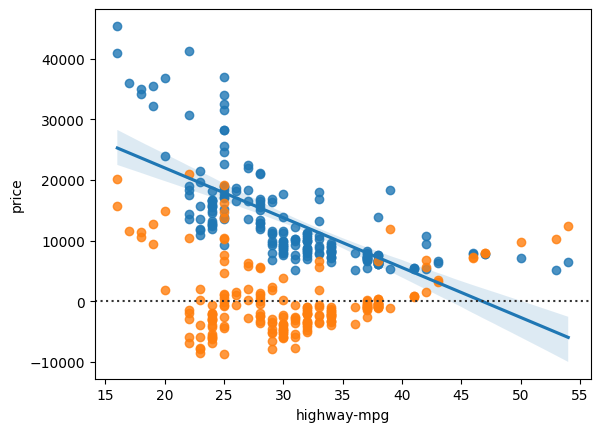

In [46]:
sns.regplot(x = 'highway-mpg' , y = 'price', data = df)
sns.residplot(x = 'highway-mpg' , y = 'price', data = df)
#plt.ylim(0.)

## Distribution Plot ?
Plots the predicted model vs actual data. Kernel Density Estimation (KDE) plots are a valuable tool for visualizing data distributions by estimating their probability density function (PDF). These plots are particularly useful in regression analysis for comparing actual and predicted values. With the deprecation of Seaborn's `distplot`, KDE plots serve as a modern and effective method for assessing model performance.

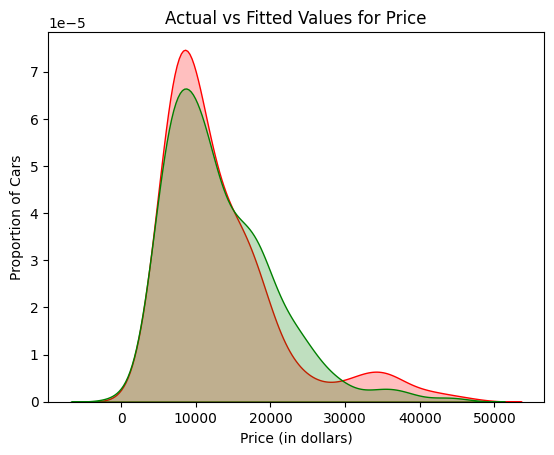

In [124]:
Y_hat = multi_lin.predict(Z)
#ax1 = sns.distplot(df['price'], hist = False, color="g", label="Actual Value")
#sns.distplot(Y_hat, hist = False, color="b", label="Fitted Values" )
sns.kdeplot(df['price'], label='Actual', fill=True, color='red')
sns.kdeplot(Y_hat, label='Predicted', fill=True, color='green')


plt.title('Actual vs Fitted Values for Price')
plt.xlabel('Price (in dollars)')
plt.ylabel('Proportion of Cars')

plt.show()

# Polynomial regression

<b>Polynomial regression</b> is a particular case of the general linear regression model or multiple linear regression models.

We get non-linear relationships by squaring or setting higher-order terms of the predictor variables.

There are different orders of polynomial regression such as:

<center> <b>Quadratic</b> $ Y = a + bx + cx^2$</center>
 and higher order polynomials. 


        3         2
-1.557 x + 204.8 x - 8965 x + 1.379e+05


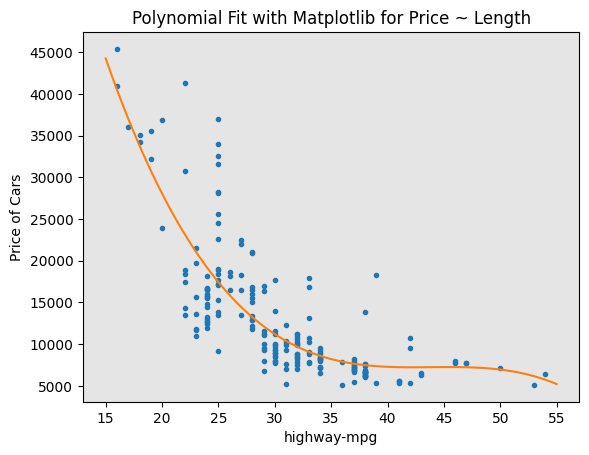

In [145]:
def PlotPolly(model, independent_variable, dependent_variabble, Name):
    x_new = np.linspace(15, 55, 100)
    y_new = model(x_new)

    plt.plot(independent_variable, dependent_variabble, '.', x_new, y_new, '-')
    plt.title('Polynomial Fit with Matplotlib for Price ~ Length')
    ax = plt.gca()
    ax.set_facecolor((0.898, 0.898, 0.898))
    fig = plt.gcf()
    plt.xlabel(Name)
    plt.ylabel('Price of Cars')

    plt.show()
    plt.close() 

x = df['highway-mpg']
y = df['price']
# numpy helps here to get the polynomial equation
f = np.polyfit(x , y , 3) # choose the polynomial degree
p = np.poly1d(f) # displays the polynomial equation
print(p)
PlotPolly(p , x , y , 'highway-mpg')

## Model Evaluation
Two methos for evaluationg the goodness of fit of a model:

- Mean squared error(MSE): defined as $$ \frac{\mathbb{\Sigma}({y_{predicted} - y_{actual}})^2}{N}$$

- R-Squared: Also called coefficient of determination, it measures the closeness of the fit to the actual data using the formula:

$$ R^2 =  \left[ 1 - \frac{\text{MSE of regression line}}{\text{MSE of the average of the data}}\right]$$

In [147]:
#mse error
